# Chronos-2: Applied Financial Time Series Forecasting

This notebook demonstrates the application of Amazon's zero-shot foundational time series model, **Chronos-2**, to financial market data. It covers two distinct quantitative strategies:

1. **Univariate Directional Forecasting:** A Long/Short strategy on the S&P 500 ETF (SPY) based on median expected drift.
2. **Cross-Sectional Market-Neutral Strategy:** A ranking strategy applied to S&P 500 constituents, following the Fischer & Krauss (2018) framework.

Reference:

Fischer, T., & Krauss, C. (2018). Deep learning with long short-term memory networks for financial market predictions. *European Journal of Operational Research*, 270(2), 654–669. https://doi.org/10.1016/j.ejor.2017.11.054

In [1]:
%pip install 'chronos-forecasting[extras]>=2.2' 'matplotlib'

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.7/72.7 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.5/140.5 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 504.9/504.9 kB 24.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 114.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.2/15.2 MB 102.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 49.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.6/88.6 kB 10.0 MB/s eta 0:00:00
  Attempting uninstall: huggingface_hub
    Found existing installation: huggingface_hub 1.17.0
    Uninstalling huggingface_hub-1.17.0:
      Successfully uninstalled huggingface_hub-1.17.0
  Attempting uninstall: transformers
    Found existing installation: transformers 5.9.0
  

In [5]:
import io
import requests
import numpy as np
import pandas as pd
import random
import yfinance as yf
import torch
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mtick
from chronos import Chronos2Pipeline

# Global configuration for plots
plt.style.use('seaborn-v0_8-whitegrid')
import warnings
warnings.filterwarnings('ignore')

#Ensures deterministic, reproducible results for the Chronos-2 pipeline.
seed = 42
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
np.random.seed(seed)
random.seed(seed)


## Initialization
Initialize the Chronos-2 pipeline once. Using `bfloat16` significantly reduces VRAM usage without sacrificing predictive accuracy, enabling rapid backtesting.

In [3]:
pipeline = Chronos2Pipeline.from_pretrained(
        f"amazon/chronos-2",
        device_map="cuda",
        dtype=torch.bfloat16,
    )

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/478M [00:00<?, ?B/s]

---
# Strategy 1: Univariate SPY Long/Short
This strategy forecasts the next-day raw return of the SPY ETF using a rolling 90-day window. Trades are executed only when the median forecast ($P_{50}$) exceeds realistic transaction costs (sourced from Interactive Brokers).

In [7]:
def fetch_and_prep_spy(start_date, end_date):
    """
    Fetches SPY data, calculates raw returns, and prepares the dummy sequence for predict_df.

    Parameters
    ----------
    start_date : str
        The start date for fetching historical data in 'YYYY-MM-DD' format.
    end_date : str
        The end date for fetching historical data in 'YYYY-MM-DD' format.

    Returns
    -------
    pandas.DataFrame
        A formatted DataFrame containing SPY prices, raw returns, and dummy dates.
    """
    print("Fetching SPY Data...")
    spy_raw = yf.download('SPY', start=start_date, end=end_date, auto_adjust=False)

    # Flatten yfinance 2D output
    df = spy_raw['Close'].squeeze().to_frame(name='Close')

    df['Raw_Return'] = df['Close'].pct_change()
    df = df.dropna().reset_index()
    df['item_id'] = 'SPY'

    # Map dates to uniform sequence to bypass predict_df weekend frequency validation
    df['Dummy_Date'] = pd.date_range(start='2000-01-01', periods=len(df), freq='D')

    return df

def run_univariate_backtest(df, pipeline, start_date, window_size=90, threshold=0.0005, cost_per_share=0.01):
    """
    Executes the rolling walk-forward backtest for the univariate strategy.

    Parameters
    ----------
    df : pandas.DataFrame
        The prepared SPY DataFrame containing historical prices and returns.
    pipeline : Chronos2Pipeline
        The initialized Chronos-2 prediction pipeline.
    start_date : str
        The start date for the backtest in 'YYYY-MM-DD' format.
    window_size : int, optional
        The number of historical days to use as context for each prediction (default is 90).
    threshold : float, optional
        The minimum predicted median raw return required to trigger a trade (default is 0.0005).
    cost_per_share : float, optional
        The simulated transaction cost per share traded (default is 0.01).

    Returns
    -------
    pandas.DataFrame
        A DataFrame containing the daily predictions, signals, and calculated strategy returns.
    """
    start_idx = df.index[df['Date'] >= start_date].tolist()[0]
    predictions = []

    print("Running Univariate Walk-Forward Backtest...")
    for i in range(start_idx, len(df)):
        train_slice = df.iloc[i - window_size : i]
        input_df = train_slice[['item_id', 'Dummy_Date', 'Raw_Return']]

        forecast_df = pipeline.predict_df(
            input_df,
            id_column="item_id",
            timestamp_column="Dummy_Date",
            target="Raw_Return",
            prediction_length=1,
            quantile_levels=[0.5]
        )

        predictions.append({
            'Date': df['Date'].iloc[i],
            'Actual_Raw_Ret': df['Raw_Return'].iloc[i],
            'Actual_Price': df['Close'].iloc[i],
            'P50': forecast_df.iloc[0]['0.5']
        })

    results = pd.DataFrame(predictions)

    # Signal Generation
    results['Signal'] = np.where(results['P50'] > threshold, 1,
                        np.where(results['P50'] < -threshold, -1, 0))
    results['Long_Signal'] = np.where(results['Signal'] == 1, 1, 0)
    results['Short_Signal'] = np.where(results['Signal'] == -1, -1, 0)

    # Gross Returns
    results['Long_Raw_Ret'] = results['Long_Signal'].shift(1) * results['Actual_Raw_Ret']
    results['Short_Raw_Ret'] = results['Short_Signal'].shift(1) * results['Actual_Raw_Ret']
    results['Combined_Raw_Ret'] = results['Signal'].shift(1) * results['Actual_Raw_Ret']

    # Transaction Costs
    results['Cost_Pct'] = cost_per_share / results['Actual_Price']
    results['Combined_Trade_Cost'] = (results['Signal'].diff().abs() > 0) * results['Cost_Pct']

    # Net Returns
    results['Net_Long_Ret'] = results['Long_Raw_Ret'] - (results['Combined_Trade_Cost'].fillna(0) / 2)
    results['Net_Short_Ret'] = (-results['Short_Raw_Ret']) - (results['Combined_Trade_Cost'].fillna(0) / 2)
    results['Net_Combined_Ret'] = results['Combined_Raw_Ret'] - results['Combined_Trade_Cost'].fillna(0)

    return results

# Execute Univariate Strategy
spy_df = fetch_and_prep_spy('2022-01-01', '2026-05-29')
spy_results = run_univariate_backtest(spy_df, pipeline, start_date='1997-01-01')

[*********************100%***********************]  1 of 1 completed

Fetching SPY Data...


### Univariate Strategy Evaluation
Visualizing the separated Long-Only/Short-Only performance and calculating the classification accuracy (Directional Accuracy & Hit Rate). Includes automated CSV and transparent graph exports.


=== UNIVARIATE ACCURACY METRICS ===
Raw Directional Accuracy: 51.45%
Active Trade Hit Rate:    44.54%
Total Trades Taken:       5667 out of 7397 days

Exported 'univariate_strategy_results.csv' and 'univariate_strategy_performance.png'


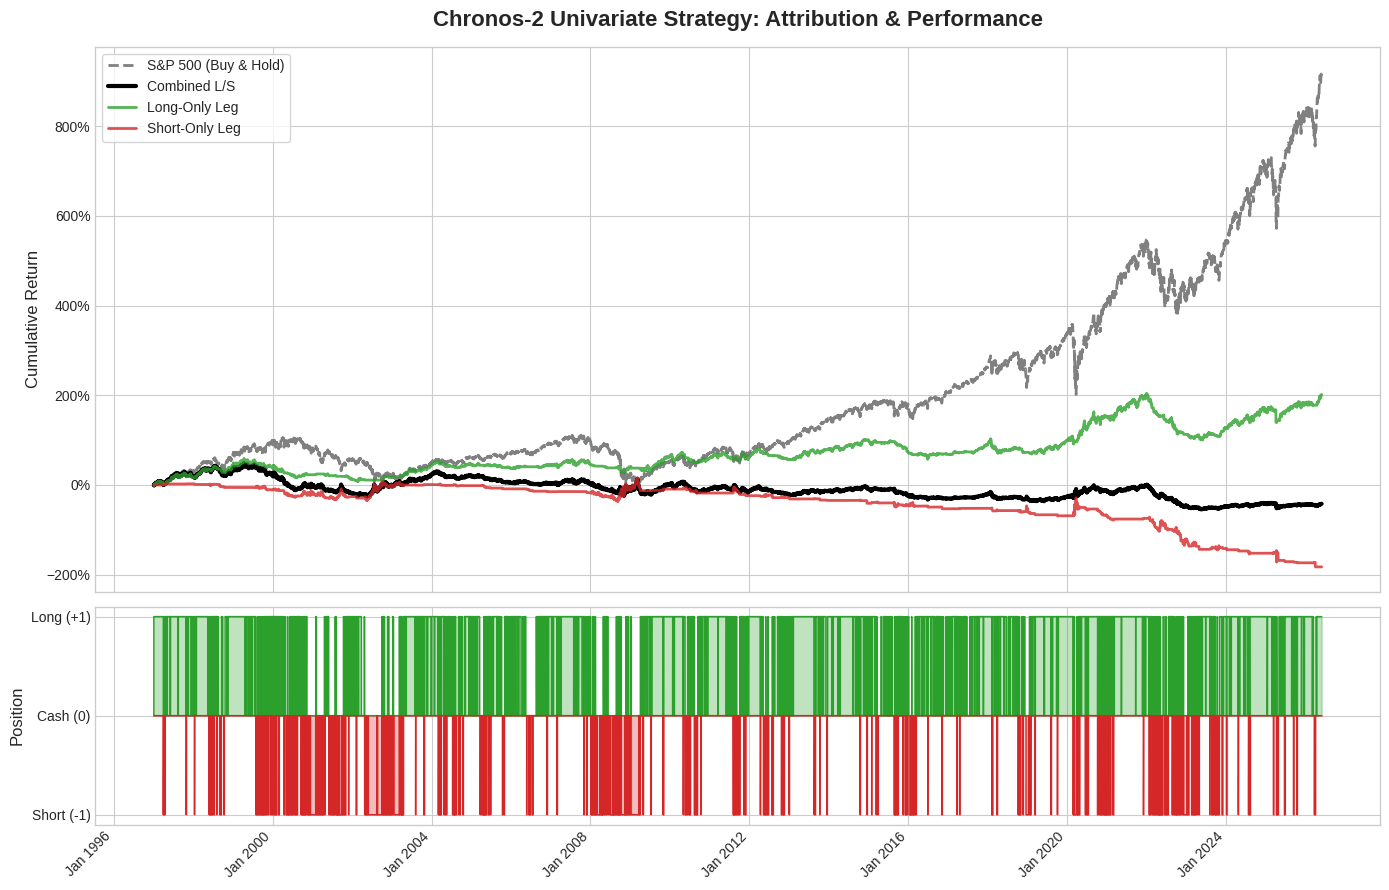

In [5]:
def evaluate_univariate_strategy(results):
    """
    Calculates accuracy metrics, plots the univariate strategy performance, and exports results.

    Parameters
    ----------
    results : pandas.DataFrame
        The output DataFrame from the univariate backtest containing strategy returns.

    Returns
    -------
    None
    """
    # Accuracy Metrics
    correct_dir = (np.sign(results['P50']) == np.sign(results['Actual_Raw_Ret'])).mean()
    active_trades = results[results['Signal'] != 0]
    hit_rate = (active_trades['Combined_Raw_Ret'] > 0).mean() if len(active_trades) > 0 else 0
    total_trades_str = f"{len(active_trades)} out of {len(results)} days"

    print("\n=== UNIVARIATE ACCURACY METRICS ===")
    print(f"Raw Directional Accuracy: {correct_dir*100:.2f}%")
    print(f"Active Trade Hit Rate:    {hit_rate*100:.2f}%")
    print(f"Total Trades Taken:       {total_trades_str}")
    print("======================================\n")

    # Plotting
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9), gridspec_kw={'height_ratios': [3, 1.2]}, sharex=True)
    fig.patch.set_alpha(0.0)
    ax1.patch.set_alpha(0.0)
    ax2.patch.set_alpha(0.0)

    cum_market = (1 + results['Actual_Raw_Ret']).cumprod() - 1
    cum_combined = (1 + results['Net_Combined_Ret']).cumprod() - 1
    cum_long = (1 + results['Net_Long_Ret']).cumprod() - 1
    cum_short = -(1 + results['Net_Short_Ret']).cumprod() + 1

    ax1.plot(results['Date'], cum_market * 100, label='S&P 500 (Buy & Hold)', color='gray', linewidth=2, linestyle='--')
    ax1.plot(results['Date'], cum_combined * 100, label='Combined L/S', color='black', linewidth=3)
    ax1.plot(results['Date'], cum_long * 100, label='Long-Only Leg', color='#2ca02c', linewidth=2, alpha=0.8)
    ax1.plot(results['Date'], cum_short * 100, label='Short-Only Leg', color='#d62728', linewidth=2, alpha=0.8)

    ax1.set_title('Chronos-2 Univariate Strategy: Attribution & Performance', fontsize=16, fontweight='bold', pad=15)
    ax1.set_ylabel('Cumulative Return', fontsize=12)
    ax1.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax1.legend(loc='upper left', frameon=True)

    # Position Panel
    ax2.plot(results['Date'], results['Long_Signal'], drawstyle='steps-post', color='#2ca02c', linewidth=1)
    ax2.fill_between(results['Date'], 0, results['Long_Signal'], color='#2ca02c', alpha=0.3, step='post', label='Long Position')
    ax2.plot(results['Date'], results['Short_Signal'], drawstyle='steps-post', color='#d62728', linewidth=1)
    ax2.fill_between(results['Date'], 0, results['Short_Signal'], color='#d62728', alpha=0.3, step='post', label='Short Position')

    ax2.set_ylabel('Position', fontsize=12)
    ax2.set_yticks([-1, 0, 1])
    ax2.set_yticklabels(['Short (-1)', 'Cash (0)', 'Long (+1)'])

    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')
    plt.tight_layout()

    # Export Data & Graph
    metrics_df = pd.DataFrame({
        'Metric': ['Raw Directional Accuracy', 'Active Trade Hit Rate', 'Total Trades Taken'],
        'Value': [f"{correct_dir*100:.2f}%", f"{hit_rate*100:.2f}%", total_trades_str]
    })
    metrics_df.to_csv('univariate_metrics_table.csv', index=False)
    results.to_csv('univariate_strategy_results.csv', index=False)
    plt.savefig('univariate_strategy_performance.png', transparent=True, dpi=300, bbox_inches='tight')
    print("Exported 'univariate_strategy_results.csv' and 'univariate_strategy_performance.png'")

    plt.show()

evaluate_univariate_strategy(spy_results)

---
# Strategy 2: Cross-Sectional Market-Neutral Strategy
Applying the Fischer & Krauss (2018) methodology. We predict the cross-sectional median expected drift for the S&P 500 constituents, ranking them to form a daily Long/Short portfolio (Top k / Bottom k).

To eliminate survivorship bias, we dynamically fetch historical constituents using a  historical S&P 500 changes CSV, ensuring we only trade the exact universe available on any given date. Missing data is forward-filled to preserve token sequence integrity.

In [6]:
def fetch_sp500_panel(start_date, end_date):
    """
    Fetches historical S&P 500 constituents from a historical changes CSV and builds a strict daily point-in-time universe map.

    Parameters
    ----------
    start_date : str
        The start date for fetching historical data in 'YYYY-MM-DD' format.
    end_date : str
        The end date for fetching historical data in 'YYYY-MM-DD' format.

    Returns
    -------
    tuple
        A tuple containing:
        - pandas.DataFrame: The melted panel data of constituent prices and returns.
        - list: A sorted list of unique dates available in the dataset.
        - dict: A mapping of each trading date to a set of active S&P 500 tickers on that date.
    """
    print("Fetching Historical S&P 500 Universe from CSV...")
    # Use the raw URL for pandas to correctly parse the GitHub CSV
    csv_url = "https://raw.githubusercontent.com/fja05680/sp500/master/S%26P%20500%20Historical%20Components%20%26%20Changes(01-17-2026).csv"

    df_hist = pd.read_csv(csv_url)
    df_hist['date'] = pd.to_datetime(df_hist['date'])
    df_hist = df_hist.sort_values('date')

    start_dt = pd.to_datetime(start_date)
    end_dt = pd.to_datetime(end_date)

    # 1. Get the latest constituents right before or on our start date
    prior_comps = df_hist[df_hist['date'] <= start_dt]
    if not prior_comps.empty:
        base_comp = prior_comps.iloc[-1]['tickers']
        base_tickers = set(str(base_comp).split(','))
    else:
        base_tickers = set()

    # 2. Get any new constituents added during our backtest window
    during_comps = df_hist[(df_hist['date'] > start_dt) & (df_hist['date'] <= end_dt)]
    during_tickers = set()
    for t_list in during_comps['tickers']:
        during_tickers.update(str(t_list).split(','))

    all_tickers = base_tickers.union(during_tickers)

    # Clean tickers for yfinance (e.g., BRK.B -> BRK-B)
    tickers = [t.strip().replace('.', '-') for t in all_tickers if pd.notna(t) and t.strip()]
    tickers = list(set(tickers))

    print(f"Identified {len(tickers)} unique historical tickers for the period. Downloading Data...")
    data = yf.download(tickers, start=start_date, end=end_date, auto_adjust=False)

    # Forward Fill to patch Yahoo data holes, drop failed downloads
    prices = data['Close'].ffill().dropna(axis=1, how='all')

    df_long = prices.reset_index().melt(id_vars='Date', var_name='item_id', value_name='Close')
    df_long = df_long.sort_values(['item_id', 'Date'])
    df_long['Raw_Return'] = df_long.groupby('item_id')['Close'].pct_change()
    df_unclipped = df_long.copy()
    df_long['Raw_Return'] = df_long['Raw_Return'].clip(lower=-0.56, upper=1.27)
    df_long = df_long.dropna()

    # Map sequence dates globally
    unique_dates = sorted(df_long['Date'].unique())
    date_map = {date: pd.Timestamp('2000-01-01') + pd.Timedelta(days=i) for i, date in enumerate(unique_dates)}
    df_long['Dummy_Date'] = df_long['Date'].map(date_map)

    # 3. Build the strict Point-in-Time Daily Universe Map
    universe_map = {}
    for dt in unique_dates:
        # Find the most recent S&P 500 list strictly on or before the current trading day
        mask = df_hist['date'] <= dt
        if mask.any():
            latest_row = df_hist[mask].iloc[-1]
            raw_tickers = str(latest_row['tickers']).split(',')
            clean_tickers = [t.strip().replace('.', '-') for t in raw_tickers if pd.notna(t) and t.strip()]
            universe_map[dt] = set(clean_tickers)
        else:
            universe_map[dt] = set()

    return df_long, unique_dates, universe_map, df_unclipped


def run_cross_sectional_backtest(df_long, unique_dates, universe_map, pipeline, start_date, end_date=None, window_size=90, k=10, cost_per_share=0.01):
    """
    Executes the Cross-Sectional Market-Neutral ranking strategy over a specific date window.

    Parameters
    ----------
    df_long : pandas.DataFrame
        The prepared panel data of all constituent returns.
    unique_dates : list
        The sorted list of valid trading dates.
    universe_map : dict
        Mapping of dates to active S&P 500 tickers to prevent universe leakage.
    pipeline : Chronos2Pipeline
        The initialized Chronos-2 prediction pipeline.
    start_date : str
        The start date for the backtest in 'YYYY-MM-DD' format.
    end_date : str, optional
        The end date for the backtest in 'YYYY-MM-DD' format (default is None, which runs to the end of the data).
    window_size : int, optional
        The number of historical days to use as context for each prediction (default is 90).
    k : int, optional
        The number of stocks to hold in each leg (Top k Long, Bottom k Short) (default is 10).
    cost_per_share : float, optional
        The simulated transaction cost per share traded (default is 0.01).

    Returns
    -------
    pandas.DataFrame
        A DataFrame containing daily portfolio returns, turnover costs, and accuracy metrics.
    """
    target_start_ts = pd.Timestamp(start_date)
    target_end_ts = pd.Timestamp(end_date) if end_date else pd.Timestamp('2100-01-01')

    # Filter for valid dates strictly within the requested window
    valid_dates = [d for d in unique_dates if target_start_ts <= d <= target_end_ts]

    if not valid_dates:
        raise ValueError(f"No valid trading dates found between {start_date} and {end_date}.")

    start_idx = unique_dates.index(valid_dates[0])
    # The loop should stop at the last valid date
    end_idx = unique_dates.index(valid_dates[-1])

    portfolio_returns = []
    prev_longs, prev_shorts = set(), set()

    print(f"Running Backtest (Window: {window_size}) from {valid_dates[0].strftime('%Y-%m-%d')} to {valid_dates[-1].strftime('%Y-%m-%d')}...")

    for i in range(start_idx, end_idx):
        current_date = unique_dates[i]
        next_date = unique_dates[i+1]

        # 1. Slice & Apply Point-in-Time Universe Filter
        cutoff_date = unique_dates[i - window_size]
        panel_slice = df_long[(df_long['Date'] >= cutoff_date) & (df_long['Date'] <= current_date)]

        active_universe = universe_map[current_date]
        panel_slice = panel_slice[panel_slice['item_id'].isin(active_universe)]

        input_df = panel_slice[['item_id', 'Dummy_Date', 'Raw_Return']]
        counts = input_df['item_id'].value_counts()
        valid_items = counts[counts >= 3].index
        input_df = input_df[input_df['item_id'].isin(valid_items)]

        # 2. Batch Inference
        forecast_df = pipeline.predict_df(
            input_df, id_column="item_id", timestamp_column="Dummy_Date",
            target="Raw_Return", prediction_length=1, quantile_levels=[0.5], batch_size=16
        )

        # 3. Ranking
        forecast_df['Rank'] = forecast_df['0.5'].rank(ascending=False)
        long_tickers = set(forecast_df[forecast_df['Rank'] <= k]['item_id'].tolist())
        short_tickers = set(forecast_df[forecast_df['Rank'] >= (len(forecast_df) - k + 1)]['item_id'].tolist())

        # 4. Realistic Turnover Cost Calculation
        trade_cost_pct = 0.0
        new_positions = (long_tickers - prev_longs).union(short_tickers - prev_shorts)
        exited_positions = (prev_longs - long_tickers).union(prev_shorts - short_tickers)

        for ticker in new_positions.union(exited_positions):
            try:
                price = panel_slice[panel_slice['item_id'] == ticker]['Close'].iloc[-1]
                trade_cost_pct += (cost_per_share / price) * (1 / (2*k))
            except IndexError:
                continue

        # 5. Returns & Accuracy
        next_day_data = df_long[df_long['Date'] == next_date].set_index('item_id')
        long_ret = np.nan_to_num(next_day_data.loc[next_day_data.index.isin(long_tickers), 'Raw_Return'].mean())
        short_ret = np.nan_to_num(next_day_data.loc[next_day_data.index.isin(short_tickers), 'Raw_Return'].mean())

        actual_median = next_day_data.loc[next_day_data.index.isin(active_universe), 'Raw_Return'].median()
        longs_actual_ret = next_day_data.loc[next_day_data.index.isin(long_tickers), 'Raw_Return']
        shorts_actual_ret = next_day_data.loc[next_day_data.index.isin(short_tickers), 'Raw_Return']

        portfolio_returns.append({
            'Date': next_date,
            'Long_Return': long_ret,
            'Short_Return': short_ret,
            'Gross_Strat': long_ret - short_ret,
            'Net_Strat': long_ret - short_ret - trade_cost_pct,
            'Turnover_Cost': trade_cost_pct,
            'Long_Acc': np.nanmean(longs_actual_ret > actual_median) if len(longs_actual_ret) > 0 else 0,
            'Short_Acc': np.nanmean(shorts_actual_ret < actual_median) if len(shorts_actual_ret) > 0 else 0
        })

        prev_longs, prev_shorts = long_tickers, short_tickers

    return pd.DataFrame(portfolio_returns)


### Institutional Strategy Evaluation
Generating the comprehensive Fischer & Krauss (2018) financial metrics table to benchmark the market-neutral strategy against the S&P 500, alongside cross-sectional classification accuracy. Includes automated CSV and transparent graph exports.

In [8]:

def calc_financial_metrics(ret_series, rf=0.04):
    """
    Calculates institutional risk and return metrics for a given return series.

    Parameters
    ----------
    ret_series : pandas.Series
        The daily return series of the strategy or benchmark.
    rf : float, optional
        The assumed annualized risk-free rate (default is RISK_FREE_RATE).

    Returns
    -------
    dict
        A dictionary containing formatted financial metrics such as Sharpe ratio,
        Sortino ratio, Maximum Drawdown, and annualized returns.
    """
    mean_ret = ret_series.mean()
    std_dev = ret_series.std()
    ann_ret = (1 + mean_ret)**252 - 1
    ann_std = std_dev * np.sqrt(252)
    ann_downside_std = ret_series[ret_series < 0].std() * np.sqrt(252)

    return {
        "Mean return (combined)": f"{mean_ret*100:.4f}%",
        "Standard error": f"{ret_series.sem()*100:.4f}%",
        "t-Statistic": f"{mean_ret / ret_series.sem() if ret_series.sem() != 0 else 0:.2f}",
        "Minimum": f"{ret_series.min()*100:.2f}%",
        "Median": f"{ret_series.median()*100:.2f}%",
        "Maximum": f"{ret_series.max()*100:.2f}%",
        "Share > 0": f"{(ret_series > 0).mean()*100:.1f}%",
        "Standard dev.": f"{std_dev*100:.2f}%",
        "Skewness": f"{ret_series.skew():.2f}",
        "Kurtosis": f"{ret_series.kurtosis():.2f}",
        "Max. drawdown": f"{((1 + ret_series).cumprod() / (1 + ret_series).cumprod().cummax() - 1).min()*100:.2f}%",
        "Return p.a.": f"{ann_ret*100:.2f}%",
        "Standard dev. p.a.": f"{ann_std*100:.2f}%",
        "Sharpe ratio p.a.": f"{(ann_ret - rf) / ann_std if ann_std != 0 else 0:.2f}",
        "Sortino ratio p.a.": f"{(ann_ret - rf) / ann_downside_std if ann_downside_std != 0 else 0:.2f}"
    }

def evaluate_cross_sectional_strategy(results, log_scale=False, long_only=False):
    """
    Prints metrics, plots the market-neutral portfolio, and exports results and tables.

    Parameters
    ----------
    results : pandas.DataFrame
        The output DataFrame from the cross-sectional backtest containing strategy returns.
    log_scale : bool, optional
        If True, plots the cumulative returns on a logarithmic scale (default is False).
    long_only : bool, optional
        If True, calculates performance metrics using only the long leg returns adjusted
        for turnover costs instead of the combined long/short net strategy (default is False).

    Returns
    -------
    None
    """
    # Print Accuracy
    long_acc, short_acc = results['Long_Acc'].mean(), results['Short_Acc'].mean()
    print("\n=== CLASSIFICATION ACCURACY ===")
    print(f"Long-Only Leg Accuracy (Beat Median):   {long_acc*100:.2f}%")
    print(f"Short-Only Leg Accuracy (Under Median): {short_acc*100:.2f}%")
    print(f"Combined Classification Accuracy:       {((long_acc + short_acc)/2)*100:.2f}%")

    # Dynamically select target series and text labels based on the flag
    if long_only:
        strat_series = results['Long_Return'] - (results['Turnover_Cost'] / 2)
        strat_label = 'Chronos Long-Only'
        file_suffix = '_long_only'
    else:
        strat_series = results['Net_Strat']
        strat_label = 'Chronos L/S Neutral'
        file_suffix = ''

    # Print Financial Table
    strat_metrics = calc_financial_metrics(strat_series)
    spy_metrics = calc_financial_metrics(results['SPY_Return'])

    print("\n" + "="*70)
    print(f"{'PERFORMANCE METRICS':^70}")
    print("="*70)
    print(f"{'Metric':<25} | {strat_label:<20} | {'S&P 500 (SPY)':<20}")
    print("-" * 70)

    print(f"{'Mean return (long-only)':<25} | {(results['Long_Return'] - (results['Turnover_Cost']/2)).mean()*100:<20.4f}% | {'N/A':<20}")
    print(f"{'Mean return (short-only)':<25} | {(-results['Short_Return'] - (results['Turnover_Cost']/2)).mean()*100:<20.4f}% | {'N/A':<20}")

    for key in strat_metrics.keys():
        if key in ["Minimum", "Standard dev.", "Max. drawdown", "Return p.a."]: print("-" * 70)
        print(f"{key:<25} | {strat_metrics[key]:<20} | {spy_metrics[key]:<20}")
    print("="*70 + "\n")

    # Plotting
    fig, ax = plt.subplots(figsize=(14, 7))
    fig.patch.set_alpha(0.0)
    ax.patch.set_alpha(0.0)

    cum_spy = (1 + results['SPY_Return']).cumprod() - 1
    cum_strat = (1 + results['Net_Strat']).cumprod() - 1
    cum_long = (1 + (results['Long_Return'] - (results['Turnover_Cost']/2))).cumprod() - 1
    cum_short_ret = (1 + (-results['Short_Return'] - (results['Turnover_Cost']/2))).cumprod() - 1

    # Apply Log Scale Shift if requested
    if log_scale:
        y_spy = (1 + cum_spy) * 100
        y_strat = (1 + cum_strat) * 100
        y_long = (1 + cum_long) * 100
        y_short = (1 + cum_short_ret) * 100

        ax.set_yscale('log')
        ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda y, pos: f"{y - 100:g}%"))
        ax.set_ylabel('Cumulative Return (Log Scale)', fontsize=12)
    else:
        y_spy = cum_spy * 100
        y_strat = cum_strat * 100
        y_long = cum_long * 100
        y_short = cum_short_ret * 100

        ax.yaxis.set_major_formatter(mtick.PercentFormatter())
        ax.set_ylabel('Cumulative Return', fontsize=12)

    # Plot lines
    ax.plot(results['Date'], y_spy, color='#1f77b4', linewidth=2.5, linestyle='--')
    ax.plot(results['Date'], y_strat, color='black', linewidth=3)
    ax.plot(results['Date'], y_long, color='#2ca02c', alpha=0.6, linewidth=1.5)
    ax.plot(results['Date'], y_short, color='#d62728', alpha=0.6, linewidth=1.5)

    ax.set_title('Chronos-2 Cross-Sectional Market-Neutral Strategy vs. Benchmark', fontsize=16, fontweight='bold', pad=15)

    # Force x-axis bounds to eliminate whitespace
    ax.set_xlim(results['Date'].min(), results['Date'].max())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

    # Normal horizontal timestamps
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=0, ha='center')
    plt.tight_layout()

    # --- Export Metrics Tables ---
    # 1. Export the accuracy metrics
    acc_df = pd.DataFrame({
        'Metric': ['Long-Only Leg Accuracy (Beat Median)', 'Short-Only Leg Accuracy (Under Median)', 'Combined Classification Accuracy'],
        'Value': [f"{long_acc*100:.2f}%", f"{short_acc*100:.2f}%", f"{((long_acc + short_acc)/2)*100:.2f}%"]
    })
    acc_df.to_csv(f'cross_sectional_accuracy_metrics{file_suffix}.csv', index=False)

    # 2. Export the full financial table
    financial_metrics_df = pd.DataFrame({
        'Metric': list(strat_metrics.keys()),
        strat_label: list(strat_metrics.values()),
        'S&P 500 (SPY)': list(spy_metrics.values())
    })

    # Prepend the leg-specific returns to match the console output safely
    top_rows = pd.DataFrame({
        'Metric': ['Mean return (long-only)', 'Mean return (short-only)'],
        strat_label: [f"{(results['Long_Return'] - (results['Turnover_Cost']/2)).mean()*100:.4f}%", f"{(-results['Short_Return'] - (results['Turnover_Cost']/2)).mean()*100:.4f}%"],
        'S&P 500 (SPY)': ['N/A', 'N/A']
    })
    financial_metrics_df = pd.concat([top_rows, financial_metrics_df], ignore_index=True)
    financial_metrics_df.to_csv(f'cross_sectional_financial_metrics{file_suffix}.csv', index=False)

    # Export Data & Graph
    results.to_csv(f'cross_sectional_market_neutral_results{file_suffix}.csv', index=False)
    plt.savefig(f'cross_sectional_market_neutral_performance{file_suffix}.png', transparent=True, dpi=300, bbox_inches='tight')
    print(f"Exported results CSV, performance PNG, and two metrics CSVs for {strat_label}.")

    plt.show()




In [ ]:
panel_df, panel_dates, universe_map, unclipped_df = fetch_sp500_panel('1996-01-01', '2026-05-29') # Desired data period for the backtest. Adjust as needed.

res_ = run_cross_sectional_backtest(
        df_long=panel_df,
        unique_dates=panel_dates,
        universe_map=universe_map,
        pipeline=pipeline,
        start_date='1997-01-01', # Start date for the backtest. Change to match desired period.
        window_size=240
    )

Fetching Historical S&P 500 Universe from CSV...
Identified 563 unique historical tickers for the period. Downloading Data...


[*********************100%***********************]  563 of 563 completed
ERROR:yfinance:
26 Failed downloads:
ERROR:yfinance:['FI', 'IPG', 'SIVB', 'PARA', 'CMA', 'CDAY', 'FLT', 'DAY', 'PEAK', 'WBA', 'MMC', 'ABC', 'CTLT', 'PKI', 'K', 'ANSS', 'HES', 'DFS', 'JNPR', 'PXD', 'ATVI', 'RE', 'DISH', 'FRC', 'MRO', 'WRK']: YFTzMissingError('possibly delisted; no timezone found')


Running Backtest (Window: 240) from 2024-01-02 to 2026-05-28...



=== CLASSIFICATION ACCURACY ===
Long-Only Leg Accuracy (Beat Median):   52.17%
Short-Only Leg Accuracy (Under Median): 50.14%
Combined Classification Accuracy:       51.16%

                         PERFORMANCE METRICS                          
Metric                    | Chronos L/S Neutral  | S&P 500 (SPY)       
----------------------------------------------------------------------
Mean return (long-only)   | 0.2112              % | N/A                 
Mean return (short-only)  | -0.0907             % | N/A                 
Mean return (combined)    | 0.1204%              | 0.0827%             
Standard error            | 0.0836%              | 0.0409%             
t-Statistic               | 1.44                 | 2.02                
----------------------------------------------------------------------
Minimum                   | -6.01%               | -5.85%              
Median                    | 0.23%                | 0.11%               
Maximum                   | 8.60% 

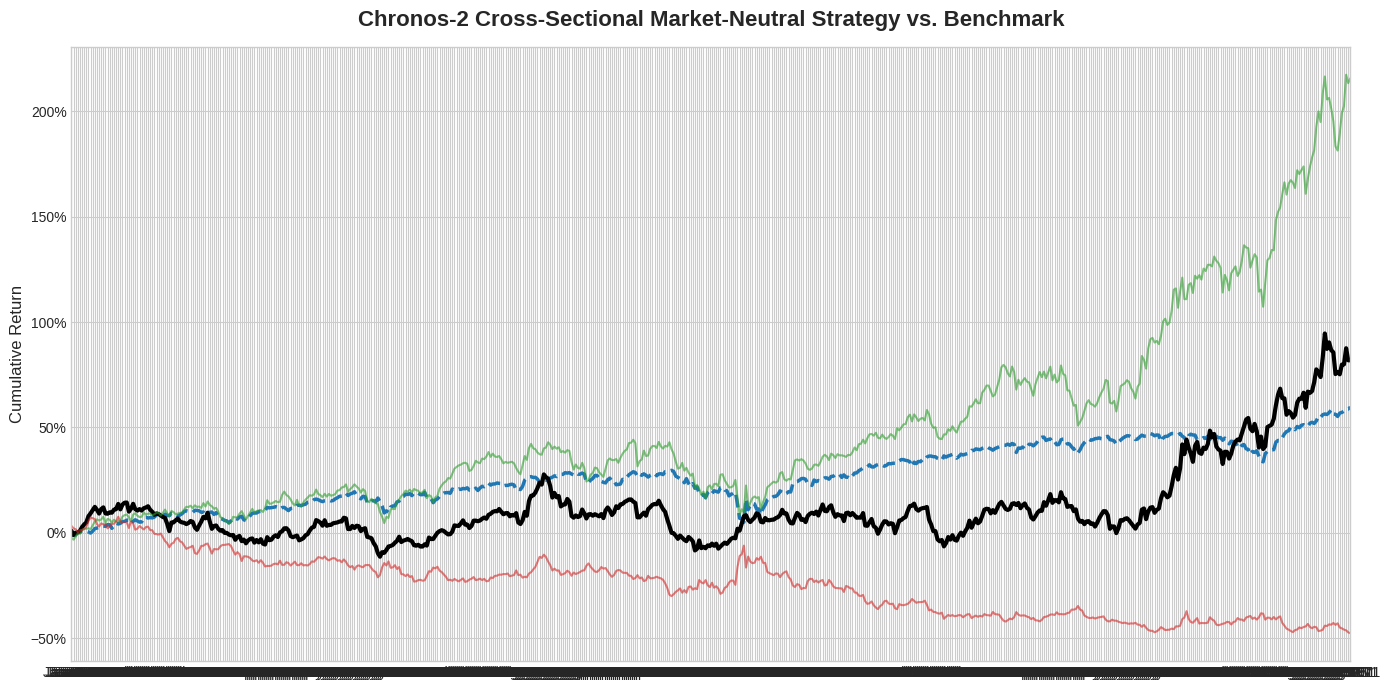

In [ ]:
# Reuse the existing spy_df from Strategy 1 to map the benchmark returns
spy_simple_returns = spy_df.set_index('Date')['Raw_Return']
res_['SPY_Return'] = res_['Date'].map(spy_simple_returns).fillna(0)

evaluate_cross_sectional_strategy(res_, False)

In [ ]:
res_.to_csv('res.csv', index=False)

In [ ]:
# 1. Ensure the Date column is in datetime format
res_['Date'] = pd.to_datetime(res_['Date'])

# 2. Filter the DataFrame for April 1, 2026 and beyond
filtered_res = res_[res_['Date'] >= '2026-04-01']

# 3. Calculate the final cumulative return for that specific window
if not filtered_res.empty:
    # We use .prod() on (1 + returns) to get the total compounding effect
    cum_return = (1 + filtered_res['Net_Strat']).prod() - 1
    sp_return = (1 + filtered_res['SPY_Return']).prod() - 1

    latest_date = filtered_res['Date'].max().strftime('%Y-%m-%d')
    print(f"Cumulative Return (Net) from 2026-04-01 to {latest_date}: {cum_return * 100:.2f}%")
    print(f"SPY Return from 2026-04-01 to {latest_date}: {sp_return * 100:.2f}%")
else:
    print("Warning: No data found from April 1, 2026 onwards in 'res_'.")

In [ ]:
#panel_df, panel_dates, universe_map, unclipped_df = fetch_sp500_panel('1996-01-01', '2026-05-29')

In [ ]:
panel_df["Raw_Return"].describe()
import seaborn as sns




# 1. Summary Statistics focused on the extreme tails
print("=== UNCLIPPED RAW RETURN PERCENTILES ===")
print(unclipped_df['Raw_Return'].describe(percentiles=[0.0005, 0.001, 0.01, 0.05, 0.5, 0.95, 0.99, 0.999, 0.9995, 0.9999]))
print("========================================\n")

# 2. Visual Distributions
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_alpha(1.0) # Ensure solid background for EDA

# Plot A: Log-Scaled Histogram
sns.histplot(unclipped_df['Raw_Return'].dropna(), bins=200, ax=ax1, color='#1f77b4')
ax1.set_yscale('log') # CRITICAL: Log scale makes extreme outlier bins visible
#ax1.set_xscale('log')
ax1.set_title('Full Unclipped Distribution (Log-Y Scale)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Daily Raw Return', fontsize=12)
ax1.set_ylabel('Frequency (Log Scale)', fontsize=12)

# Plot B: Scatter Plot over time
ax2.scatter(unclipped_df['Date'], unclipped_df['Raw_Return'], alpha=0.4, color='#d62728', s=4)
ax2.set_title('Raw Returns Over Time (Spotting Glitches)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Date', fontsize=12)
ax2.set_ylabel('Daily Raw Return', fontsize=12)
ax2.axhline(0, color='black', linewidth=1)

ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=0, ha='center')

plt.tight_layout()
plt.show()

# 3. Isolate the extreme anomalies to manually verify them
print("\n=== TOP 10 EXTREME POSITIVE RETURNS ===")
print(panel_df.nlargest(10, 'Raw_Return')[['Date', 'item_id', 'Raw_Return', 'Close']])

print("\n=== TOP 10 EXTREME NEGATIVE RETURNS ===")
print(panel_df.nsmallest(10, 'Raw_Return')[['Date', 'item_id', 'Raw_Return', 'Close']])

In [ ]:
res_ = pd.read_csv("res2024.csv")

In [ ]:
import io
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.dates as mdates


# 1. Prepare data and ensure correct format
res_['Date'] = pd.to_datetime(res_['Date'])
res_ = res_.sort_values('Date').reset_index(drop=True)

# 2. Replicate the notebook's exact log-scale data transformations
cum_spy = (1 + res_['SPY_Return']).cumprod() - 1
cum_strat = (1 + res_['Net_Strat']).cumprod() - 1
cum_long = (1 + (res_['Long_Return'] - (res_['Turnover_Cost'] / 2))).cumprod() - 1
cum_short_ret = (1 + (-res_['Short_Return'] - (res_['Turnover_Cost'] / 2))).cumprod() - 1

y_spy = (1 + cum_spy) * 100
y_strat = (1 + cum_strat) * 100
y_long = (1 + cum_long) * 100
y_short = (1 + cum_short_ret) * 100

# 3. Initialize Figure and Axis with Transparency
fig, ax = plt.subplots(figsize=(14, 7))
fig.patch.set_alpha(0.0)  # Transparent figure background
ax.patch.set_alpha(0.0)   # Transparent plot axis background

# Apply Log Scale configuration exactly as written in your notebook
ax.set_yscale('log')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda y, pos: f"{y - 100:g}%"))
ax.set_ylabel('Cumulative Return (Log Scale)', fontsize=12)
ax.set_title('Chronos-2 Cross-Sectional Market-Neutral Strategy vs. Benchmark', fontsize=16, fontweight='bold', pad=15)

# Lock strict spatial limits to prevent jumping/stretching during animation
ax.set_xlim(res_['Date'].min(), res_['Date'].max())
all_y = pd.concat([y_spy, y_strat, y_long, y_short])
y_min, y_max = all_y.min(), all_y.max()
ax.set_ylim(y_min / 1.05, y_max * 1.05)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=0, ha='center')

# Create the lines with your exact color codes, styles, weights, and alphas
line_spy, = ax.plot([], [], color='#1f77b4', linewidth=2.5, linestyle='--')
line_strat, = ax.plot([], [], color='black', linewidth=3)
line_long, = ax.plot([], [], color='#2ca02c', alpha=0.6, linewidth=1.5)
line_short, = ax.plot([], [], color='#d62728', alpha=0.6, linewidth=1.5)

plt.tight_layout()

# 4. Generate frames manually into memory
frames = []
num_frames = 200  # 200 frames total (creates exactly 20 seconds at 10 fps)
total_points = len(res_)

print("Rendering high-resolution frames...")
for frame in range(num_frames):
    # Calculate timeline slice index for the current frame
    idx = int((frame + 1) / num_frames * total_points)
    idx = min(idx, total_points)

    dates_slice = res_['Date'].iloc[:idx]

    # Update line vectors
    line_spy.set_data(dates_slice, y_spy.iloc[:idx])
    line_strat.set_data(dates_slice, y_strat.iloc[:idx])
    line_long.set_data(dates_slice, y_long.iloc[:idx])
    line_short.set_data(dates_slice, y_short.iloc[:idx])

    # Save frame state using identical parameters to your static notebook image (dpi=300, bbox_inches='tight')
    buf = io.BytesIO()
    fig.savefig(buf, format='png', transparent=True, facecolor='none', dpi=300, bbox_inches='tight')
    buf.seek(0)

    # Open with PIL and append a deep copy to memory list
    frames.append(Image.open(buf).copy())
    buf.close()

plt.close(fig)

# 5. Compile and save the GIF using Pillow directly
# duration=100ms per frame * 200 frames = 20,000ms (Exactly 20 seconds)
# disposal=2 forces clearing old frame layers so transparency doesn't overlap/smear
print("Compiling crisp transparent GIF...")
frames[0].save(
    'strategy_returns_replication.gif',
    save_all=True,
    append_images=frames[1:],
    duration=100,
    loop=0,
    disposal=2
)

print("Animation complete! 'strategy_returns_replication.gif' has been generated with zero pixelation.")

NameError: name 'res_2024' is not defined

In [ ]:
# 1. Delete the massive frames list from memory
if 'frames' in locals():
    del frames

# 2. Force Python's Garbage Collector to free the RAM immediately
import gc
gc.collect()

In [ ]:
# 1. Ensure Date column is in datetime format and sorted
res_['Date'] = pd.to_datetime(res_['Date'])
res_ = res_.sort_values('Date').reset_index(drop=True)

# 2. Define the 4 distinct periods based on your horizons
# Using contiguous ranges to prevent data gaps while matching your eras
periods = {
    "Period_1_Until_2003": (res_['Date'].min(), pd.to_datetime("2003-12-31")),
    "Period_2_2004_2008": (pd.to_datetime("2004-01-01"), pd.to_datetime("2007-12-31")),
    "Period_3_2008_2020": (pd.to_datetime("2008-01-01"), pd.to_datetime("2019-12-31")),
    "Period_4_2020_to_End": (pd.to_datetime("2020-01-01"), res_['Date'].max())
}

# 3. Loop through each period, slice, recalculate metrics, and export
for period_name, (start_date, end_date) in periods.items():
    # Filter the dataset for the specific time frame
    df_period = res_[(res_['Date'] >= start_date) & (res_['Date'] <= end_date)].copy()

    # Skip if no data falls within this window
    if df_period.empty:
        print(f"Skipping {period_name}: No data found in this date range.")
        continue

    # Re-index to ensure cumulative compounding resets to 0% at the start of this period
    df_period = df_period.sort_values('Date').reset_index(drop=True)

    # Calculate fresh cumulative returns for this slice
    cum_spy = (1 + df_period['SPY_Return']).cumprod() - 1
    cum_strat = (1 + df_period['Net_Strat']).cumprod() - 1
    cum_long = (1 + (df_period['Long_Return'] - (df_period['Turnover_Cost'] / 2))).cumprod() - 1
    cum_short_ret = (1 + (-df_period['Short_Return'] - (df_period['Turnover_Cost'] / 2))).cumprod() - 1

    # Apply Log Scale shifts (matching your notebook's exact presentation logic)
    y_spy = (1 + cum_spy) * 100
    y_strat = (1 + cum_strat) * 100
    y_long = (1 + cum_long) * 100
    y_short = (1 + cum_short_ret) * 100

    # Initialize Figure and Axes
    fig, ax = plt.subplots(figsize=(14, 7))
    fig.patch.set_alpha(0.0)  # Replicate transparent figure background
    ax.patch.set_alpha(0.0)   # Replicate transparent axes background

    # Apply Log Scale configuration
    ax.set_yscale('log')
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda y, pos: f"{y - 100:g}%"))
    ax.set_ylabel('Cumulative Return (Log Scale)', fontsize=12)

    # Set localized title showing the current regime range
    date_str_start = df_period['Date'].min().strftime('%Y-%m-%d')
    date_str_end = df_period['Date'].max().strftime('%Y-%m-%d')
    ax.set_title(
        f'Chronos-2 CS Market-Neutral Strategy vs. Benchmark ({date_str_start} to {date_str_end})',
        fontsize=16, fontweight='bold', pad=15
    )

    # Force strict x-axis bounds to eliminate any margins or padding whitespace
    ax.set_xlim(df_period['Date'].min(), df_period['Date'].max())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=0, ha='center')

    # Plot the 4 lines with identical weights, colors, and transparency styles
    ax.plot(df_period['Date'], y_spy, color='#1f77b4', linewidth=2.5, linestyle='--')
    ax.plot(df_period['Date'], y_strat, color='black', linewidth=3)
    ax.plot(df_period['Date'], y_long, color='#2ca02c', alpha=0.6, linewidth=1.5)
    ax.plot(df_period['Date'], y_short, color='#d62728', alpha=0.6, linewidth=1.5)

    plt.tight_layout()

    # Save the output file matching original export constraints (DPI=300, bbox_inches='tight')
    filename = f'cross_sectional_performance_{period_name}.png'
    plt.savefig(filename, transparent=True, dpi=300, bbox_inches='tight')
    plt.close(fig)

    print(f"Successfully generated and saved: {filename}")

### In-Sample Hyperparameter Tuning (2024)

In [ ]:
## 1. Fetch data starting early enough to support the massive 240-day lookback window
#panel_df, panel_dates, universe_map = fetch_sp500_panel('2022-12-01', '2026-01-01')
#
## 2. Define the Hyperparameter Grid
#window_sizes = [5, 20, 80, 160, 240]
#tuning_results = []
#
#print("\n--- IN-SAMPLE HYPERPARAMETER TUNING (2024) ---")
#
#for w in window_sizes:
#    # Run backtest exclusively on 2024 data
#    res_2024 = run_cross_sectional_backtest(
#        df_long=panel_df,
#        unique_dates=panel_dates,
#        universe_map=universe_map,
#        pipeline=pipeline,
#        start_date='2024-01-01',
#        end_date='2024-12-31',
#        window_size=240
#    )
#
#    # Evaluate the Net Strategy's Sharpe Ratio
#    metrics = calc_financial_metrics(res_2024['Net_Strat'])
#    sharpe = float(metrics['Sharpe ratio p.a.'].replace('%', ''))
#    net_ret = float(metrics['Return p.a.'].replace('%', ''))
#
#    tuning_results.append({'Window Size': w, 'Sharpe Ratio': sharpe, 'Net Return p.a. (%)': net_ret})
#    print(f"-> Window {w} Days | Sharpe: {sharpe} | Net Return: {net_ret}%")
#
## 3. View the best parameter
#tuning_df = pd.DataFrame(tuning_results)
#best_window = tuning_df.loc[tuning_df['Sharpe Ratio'].idxmax()]['Window Size']
#
#print(f"\nOptimization Complete. Best Window Size for 2024 (by Sharpe Ratio): {int(best_window)} Days")
#

### Out-of-Sample Validation (2025)

In [ ]:
#print(f"\n--- OUT-OF-SAMPLE VALIDATION (2025) USING WINDOW = {int(best_window)} ---")
#
## Run strictly on 2025 using the mathematically optimal window from 2024
#out_of_sample_results = run_cross_sectional_backtest(
#    df_long=panel_df,
#    unique_dates=panel_dates,
#    universe_map=universe_map,
#    pipeline=pipeline,
#    start_date='2025-01-01',
#    end_date='2025-12-31',
#    window_size=int(best_window)
#)

In [ ]:
## Reuse the existing spy_df from Strategy 1 to map the benchmark returns
#spy_simple_returns = spy_df.set_index('Date')['Raw_Return']
#out_of_sample_results['SPY_Return'] = out_of_sample_results['Date'].map(spy_simple_returns).fillna(0)

#evaluate_cross_sectional_strategy(out_of_sample_results)